In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import re
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize



from sklearn.metrics import (
    roc_auc_score,     
    confusion_matrix, 
    precision_score, 
    recall_score,     
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
csv_files = glob.glob(os.path.join('../../data/azure_pm/balanced_dataset_safezone/', '*.csv'))
dfs = [pd.read_csv(f) for f in csv_files]
df_union = pd.concat(dfs, ignore_index=True)

df = df_union.copy()
df = df.sort_values(by='datetime').reset_index(drop=True)

target_mapping = {
    "0": 0,
    "comp1": 1,
    "comp2": 2,
    "comp3": 3,
    "comp4": 4
}

df["target"] = df["target"].map(target_mapping)


df.to_csv("../../data/azure_pm/balanced_dataset_safezone/merged_dataset/balanced_azure_pm.csv")

Dataset shape: (2244, 66)
Feature columns: 63

Train set shape: (1795, 63)
Test set shape: (449, 63)

Training RandomForest...
RandomForest - ROC AUC (macro): 0.9999, Accuracy: 0.9866
Training XGBoost...
XGBoost - ROC AUC (macro): 0.9999, Accuracy: 0.9911
Training LightGBM...
LightGBM - ROC AUC (macro): 1.0000, Accuracy: 0.9911
Training CatBoost...
CatBoost - ROC AUC (macro): 1.0000, Accuracy: 0.3113

DETAILED EVALUATION RESULTS

SUMMARY OF ALL METRICS:
       Model ROC_AUC_macro ROC_AUC_micro Normalized_AUC Youden_Index Precision_macro Precision_micro Recall_macro Recall_micro Accuracy
RandomForest        0.9999        0.9999         0.9998       0.9775          0.9770          0.9866       0.9806       0.9866   0.9866
     XGBoost        0.9999        0.9999         0.9998       0.9893          0.9818          0.9911       0.9913       0.9911   0.9911
    LightGBM        1.0000        1.0000         1.0000       0.9893          0.9818          0.9911       0.9913       0.9911   0.991

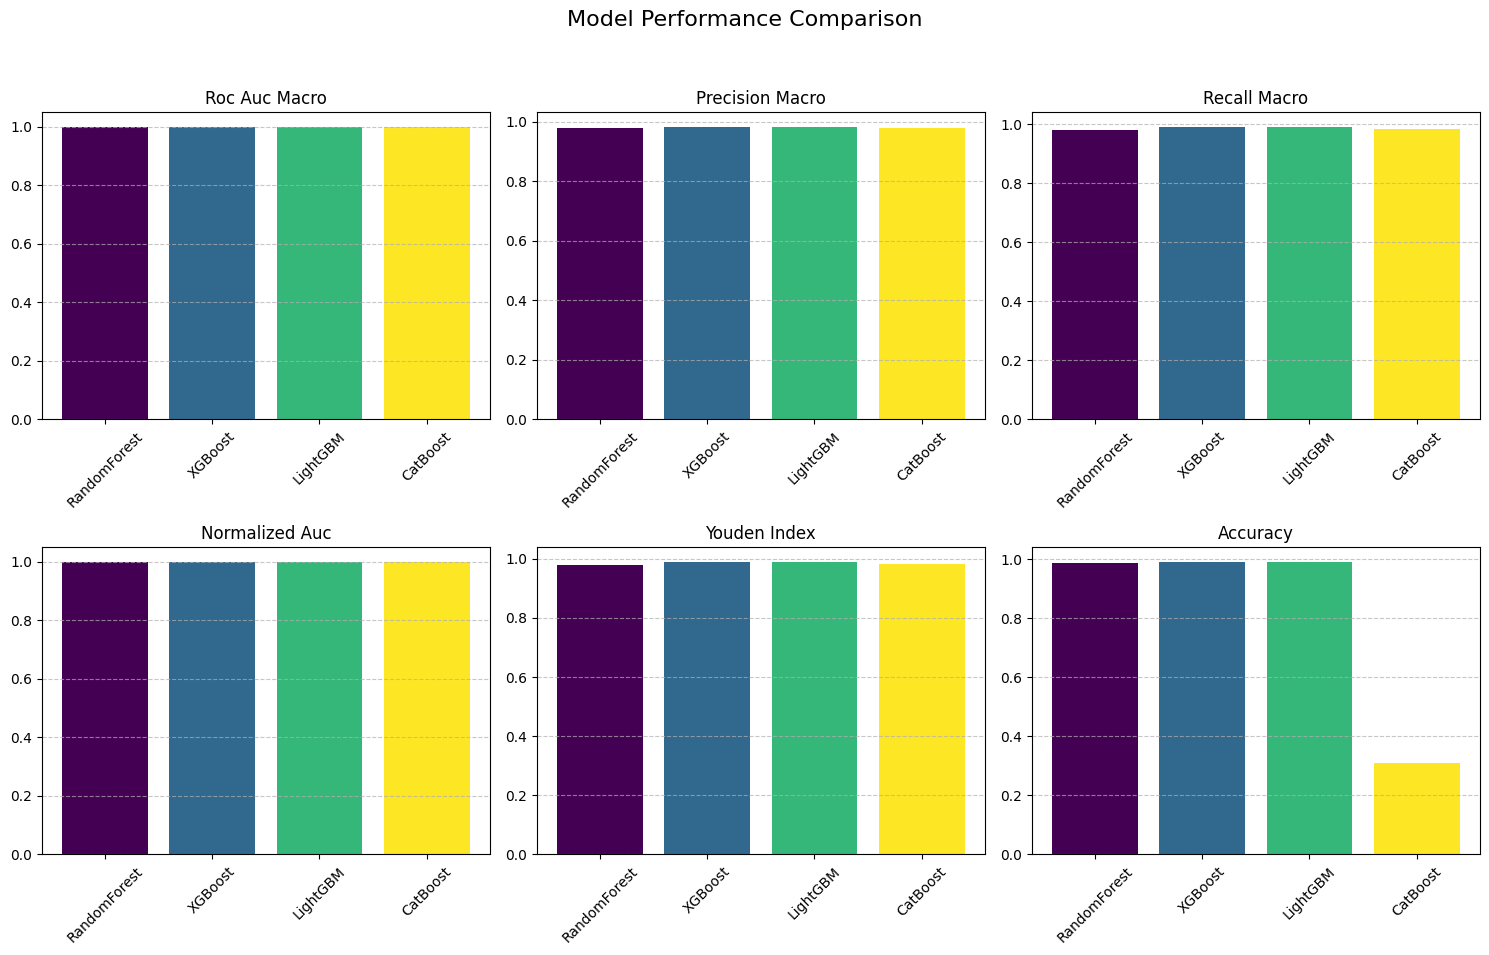

In [3]:
class MultiClassPredictiveMaintenanceEvaluator:
    """
    Comprehensive evaluator for multi-class predictive maintenance models.
    """

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {}
        self.results = {}

    def prepare_data(self, df, test_size=0.2, target_col='target'):
        """
        Prepare and split data, ensuring temporal sequence and correct data formats.
        """
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.sort_values(by='datetime').reset_index(drop=True)

        exclude_cols = ['datetime', 'failure', 'target', '']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        X = df[feature_cols].fillna(0)
        y = df[target_col]

        split_index = int(len(df) * (1 - test_size))
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

        # Convert y_train and y_test to 1D NumPy arrays to ensure compatibility
        y_train = y_train.values
        y_test = y_test.values

        print(f"Dataset shape: {df.shape}")
        print(f"Feature columns: {len(feature_cols)}")
        print(f"\nTrain set shape: {X_train.shape}")
        print(f"Test set shape: {X_test.shape}\n")

        return X_train, X_test, y_train, y_test

    def initialize_models(self):
        """
        Initialize all machine learning models.
        """
        self.models = {
            'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=self.random_state, n_jobs=-1),
            'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, eval_metric='mlogloss'),
            'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, verbose=-1),
            'CatBoost': cb.CatBoostClassifier(iterations=100, depth=6, random_seed=self.random_state, verbose=False)
        }

    def calculate_metrics(self, y_true, y_pred, y_pred_proba):
        """
        Calculate comprehensive metrics for multi-class classification.
        """
        metrics = {}
        classes = np.unique(y_true)
        
        # 1. ROC AUC (macro and micro)
        metrics['ROC_AUC_macro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
        metrics['ROC_AUC_micro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='micro')

        # 2. Normalized AUC
        per_class_aucs = [roc_auc_score(y_true == c, y_pred_proba[:, i]) for i, c in enumerate(classes)]
        metrics['Normalized_AUC'] = np.mean([(auc - 0.5) / 0.5 for auc in per_class_aucs])

        # 3. Youden Index
        youden_scores = []
        for i, c in enumerate(classes):
            y_true_binary = (y_true == c)
            y_pred_binary = (y_pred == c)
            tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden_scores.append(sensitivity + specificity - 1)
        metrics['Youden_Index'] = np.mean(youden_scores)
        
        # 4. Precision (macro and micro)
        metrics['Precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Precision_micro'] = precision_score(y_true, y_pred, average='micro', zero_division=0)

        # 5. Recall (macro and micro)
        metrics['Recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Recall_micro'] = recall_score(y_true, y_pred, average='micro', zero_division=0)
        
        metrics['Accuracy'] = np.mean(y_true == y_pred)
        return metrics

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):
        """
        Train all models and evaluate their performance.
        """
        X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_train.columns]
        X_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_test.columns]

        self.initialize_models()
        self.results = {}

        for model_name, model in self.models.items():
            print(f"Training {model_name}...")
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)
            metrics = self.calculate_metrics(y_test, y_pred, y_pred_proba)

            self.results[model_name] = {'metrics': metrics, 'y_pred': y_pred}
            print(f"{model_name} - ROC AUC (macro): {metrics['ROC_AUC_macro']:.4f}, Accuracy: {metrics['Accuracy']:.4f}")

    def print_detailed_results(self, y_test):
        """
        Print detailed classification reports and confusion matrices.
        """
        print("\n" + "="*80 + "\nDETAILED EVALUATION RESULTS\n" + "="*80)
        summary_data = [{'Model': name, **{k: f"{v:.4f}" for k, v in res['metrics'].items()}}
                        for name, res in self.results.items()]
        
        print("\nSUMMARY OF ALL METRICS:")
        print(pd.DataFrame(summary_data).to_string(index=False))

        for model_name, result in self.results.items():
            print(f"\n{'-'*60}\nDETAILED RESULTS FOR {model_name}\n{'-'*60}")
            print("Classification Report:\n", classification_report(y_test, result['y_pred']))
            print("Confusion Matrix:\n", confusion_matrix(y_test, result['y_pred']))

    def plot_results(self, figsize=(15, 10)):
        """
        Create and display visualizations of model performance.
        """
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Model Performance Comparison', fontsize=16)
        axes = axes.ravel()
        
        metrics_to_plot = ['ROC_AUC_macro', 'Precision_macro', 'Recall_macro', 'Normalized_AUC', 'Youden_Index', 'Accuracy']
        model_names = list(self.results.keys())

        for i, metric in enumerate(metrics_to_plot):
            ax = axes[i]
            scores = [self.results[model]['metrics'][metric] for model in model_names]
            ax.bar(model_names, scores, color=plt.cm.viridis(np.linspace(0, 1, len(model_names))))
            ax.set_title(metric.replace('_', ' ').title())
            ax.tick_params(axis='x', labelrotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


def run_complete_evaluation(df):
    """
    Run the complete evaluation pipeline.
    """
    evaluator = MultiClassPredictiveMaintenanceEvaluator(random_state=42)
    X_train, X_test, y_train, y_test = evaluator.prepare_data(df)
    evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    evaluator.print_detailed_results(y_test)
    evaluator.plot_results()
    return evaluator

# --- Main Execution ---
df = pd.read_csv("../../data/azure_pm/balanced_dataset_safezone/merged_dataset/balanced_azure_pm.csv")
evaluator_results = run_complete_evaluation(df)